In [9]:
!pip install pycaret
!pip install tensorflow
!pip install wordcloud
!pip install nltk
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.1 MB/s eta 0:00:00


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords

# Import Sastrawi untuk Stemming dan Stopword Bahasa Indonesia
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [11]:
# Load dataset
df = pd.read_csv('/content/Data Sentimen MBG (1).csv')

# Hapus kolom yang berisi NaN
cols_to_drop = [col for col in df.columns if col.startswith('Unnamed') or df[col].isnull().all()]
df_clean = df.drop(columns=cols_to_drop)

# Rename kolom
df_clean = df_clean.rename(columns={
    'text': 'komentar',
    'public': 'sentimen',
    'published at': 'published_at'
})

# Hapus baris dengan missing values
df_clean = df_clean.dropna(subset=['komentar', 'sentimen']).reset_index(drop=True)

print(f"Shape setelah cleaning: {df_clean.shape}")
print(f"Kolom setelah cleaning: {df_clean.columns.tolist()}")
print(f"\nDistribusi sentimen:")
print(df_clean['sentimen'].value_counts())



Shape setelah cleaning: (6419, 5)
Kolom setelah cleaning: ['author', 'published_at', 'like_count', 'komentar', 'sentimen']

Distribusi sentimen:
sentimen
Negatif    6418
              1
Name: count, dtype: int64


In [15]:
# TEXT CLEANING (Pembersihan Teks)
def text_cleaning(text):
    """
    Melakukan pembersihan teks dengan langkah-langkah:
    1. Case Folding - Mengubah semua huruf menjadi lowercase
    2. URL Removal - Menghapus link http/https
    3. Mention Removal - Menghapus username (@username)
    4. Hashtag Removal - Menghapus simbol tagar (#)
    5. Punctuation & Number Removal - Menghapus angka, tanda baca, karakter spesial
    6. Whitespace Removal - Menghapus spasi berlebih
    """
    if pd.isna(text):
        return ""

    # 1. Case Folding - Ubah ke lowercase
    text = str(text).lower()

    # 2. URL Removal - Hapus link http/https
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Mention Removal - Hapus mention (@username)
    text = re.sub(r'@\w+', '', text)

    # 4. Hashtag Removal - Hapus simbol tagar (#)
    text = re.sub(r'#\w+', '', text)

    # 5. Punctuation & Number Removal - Hapus angka, tanda baca, karakter spesial
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Hanya huruf dan spasi
    text = re.sub(r'\d+', '', text)  # Hapus angka

    # 6. Whitespace Removal - Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

print("Menerapkan text cleaning...")
df_clean['tahap1_cleaned'] = df_clean['komentar'].apply(text_cleaning)

# Tampilkan contoh hasil
print("\nContoh hasil Text Cleaning:")
for i in range(min(3, len(df_clean))):
    print(f"\nOriginal: {df_clean['komentar'].iloc[i][:100]}...")
    print(f"Cleaned : {df_clean['tahap1_cleaned'].iloc[i][:100]}...")


# NORMALIZATION (Normalisasi Slang)
# Kamus kata tidak baku (slang) ke kata baku
slang_dict = {
    # Kata sehari-hari
    'gak': 'tidak', 'ga': 'tidak', 'nggak': 'tidak', 'gk': 'tidak',
    'tdk': 'tidak', 'enggak': 'tidak', 'kagak': 'tidak',

    # Kata ganti
    'gw': 'saya', 'gue': 'saya', 'lo': 'kamu', 'lu': 'kamu',
    'gua': 'saya', 'aku': 'saya', 'kamu': 'anda',

    # Kata kerja
    'jg': 'juga', 'jga': 'juga', 'juge': 'juga',
    'sdh': 'sudah', 'udah': 'sudah', 'udh': 'sudah',
    'blm': 'belum', 'blum': 'belum',
    'msh': 'masih', 'masi': 'masih',
    'bgt': 'sangat', 'banget': 'sangat',
    'bgtt': 'sangat', 'bngt': 'sangat',

    # Kata sifat
    'serem': 'seram', 'seremmm': 'seram',
    'seneng': 'senang', 'senengg': 'senang',
    'bosen': 'bosan', 'bosenin': 'bosan',

    # Kata tanya
    'knp': 'kenapa', 'krn': 'karena', 'karna': 'karena',
    'utk': 'untuk', 'untk': 'untuk',

    # Lainnya
    'aja': 'saja', 'ajah': 'saja',
    'dgn': 'dengan', 'dg': 'dengan',
    'tp': 'tetapi', 'tpi': 'tetapi',
    'si': 'sih', 'sih': 'sih',
    'dong': 'dong', 'deh': 'deh',
    'nih': 'ini', 'nah': 'nah',
    'bro': 'saudara', 'gan': 'saudara',
    'org': 'orang', 'org2': 'orang',
    'mkn': 'makan', 'minum': 'minum',
    'kyk': 'seperti', 'kayak': 'seperti',
    'klo': 'kalau', 'kalo': 'kalau',
    'dr': 'dari', 'daripada': 'daripada',
    'pke': 'pakai', 'pake': 'pakai'
}

def normalize_text(text):
    """
    Mengubah kata tidak baku (slang) menjadi kata baku
    """
    if pd.isna(text) or text == "":
        return ""

    words = text.split()
    normalized_words = []

    for word in words:
        if word in slang_dict:
            normalized_words.append(slang_dict[word])
        else:
            normalized_words.append(word)

    return ' '.join(normalized_words)

print("Menerapkan normalisasi slang...")
df_clean['tahap2_normalized'] = df_clean['tahap1_cleaned'].apply(normalize_text)
print("\nContoh hasil Normalisasi:")
for i in range(min(3, len(df_clean))):
    print(f"\nSebelum: {df_clean['tahap1_cleaned'].iloc[i][:100]}...")
    print(f"Sesudah: {df_clean['tahap2_normalized'].iloc[i][:100]}...")




Menerapkan text cleaning...

Contoh hasil Text Cleaning:

Original: Penguasa dan Pelaksana Program MBG menjadi Penguasa Naga ke 10 (dari Penguasa 9 Naga)...
Cleaned : penguasa dan pelaksana program mbg menjadi penguasa naga ke dari penguasa naga...

Original: anaknya makan 1x bapaknya penganguran.....
Cleaned : anaknya makan x bapaknya penganguran...

Original: Rusak lah negara kalau Nepotisme, korupsi semakin terang terangan di pelihara.. MBG sudah di siapkan...
Cleaned : rusak lah negara kalau nepotisme korupsi semakin terang terangan di pelihara mbg sudah di siapkan un...
Menerapkan normalisasi slang...

Contoh hasil Normalisasi:

Sebelum: penguasa dan pelaksana program mbg menjadi penguasa naga ke dari penguasa naga...
Sesudah: penguasa dan pelaksana program mbg menjadi penguasa naga ke dari penguasa naga...

Sebelum: anaknya makan x bapaknya penganguran...
Sesudah: anaknya makan x bapaknya penganguran...

Sebelum: rusak lah negara kalau nepotisme korupsi semakin terang terangan di

In [16]:
# TOKENIZATION (Tokenisasi)
def tokenize_text(text):
    """
    Memecah teks menjadi token-token (kata per kata)
    """
    if pd.isna(text) or text == "":
        return []

    # Pisahkan berdasarkan spasi
    tokens = text.split()
    return tokens

print("Menerapkan tokenisasi...")
df_clean['tahap3_tokens'] = df_clean['tahap2_normalized'].apply(tokenize_text)
print("\nContoh hasil Tokenisasi:")
for i in range(min(3, len(df_clean))):
    print(f"\nText: {df_clean['tahap2_normalized'].iloc[i][:100]}...")
    print(f"Token: {df_clean['tahap3_tokens'].iloc[i][:15]}...")
df_clean['jumlah_token'] = df_clean['tahap3_tokens'].apply(len)
print(f"\nStatistik jumlah token per komentar:")
print(f"  Rata-rata: {df_clean['jumlah_token'].mean():.2f} token")
print(f"  Min: {df_clean['jumlah_token'].min()} token")
print(f"  Max: {df_clean['jumlah_token'].max()} token")

Menerapkan tokenisasi...

Contoh hasil Tokenisasi:

Text: penguasa dan pelaksana program mbg menjadi penguasa naga ke dari penguasa naga...
Token: ['penguasa', 'dan', 'pelaksana', 'program', 'mbg', 'menjadi', 'penguasa', 'naga', 'ke', 'dari', 'penguasa', 'naga']...

Text: anaknya makan x bapaknya penganguran...
Token: ['anaknya', 'makan', 'x', 'bapaknya', 'penganguran']...

Text: rusak lah negara kalau nepotisme korupsi semakin terang terangan di pelihara mbg sudah di siapkan un...
Token: ['rusak', 'lah', 'negara', 'kalau', 'nepotisme', 'korupsi', 'semakin', 'terang', 'terangan', 'di', 'pelihara', 'mbg', 'sudah', 'di', 'siapkan']...

Statistik jumlah token per komentar:
  Rata-rata: 16.99 token
  Min: 0 token
  Max: 429 token


In [17]:
# STOPWORD REMOVAL (Penghapusan Stopword)
# Menggunakan Sastrawi untuk stopword removal bahasa Indonesia
factory_stopword = StopWordRemoverFactory()
stopword_remover = factory_stopword.create_stop_word_remover()
custom_stopwords = {
    'yg', 'yang', 'dan', 'di', 'dari', 'ini', 'itu', 'adalah', 'untuk',
    'dengan', 'pada', 'ke', 'dapat', 'dalam', 'juga', 'akan', 'atau',
    'karena', 'telah', 'bisa', 'saya', 'kamu', 'dia', 'mereka', 'kami',
    'kita', 'anda', 'ya', 'jadi', 'saja', 'sudah', 'belum', 'masih',
    'sangat', 'tidak', 'bukan', 'iya', 'wah', 'hehe', 'haha', 'loh',
    'kok', 'kan', 'dong', 'deh', 'sih', 'pun', 'lah', 'nah', 'nih'
}

def remove_stopwords(tokens):
    """
    Menghapus stopword dari token menggunakan Sastrawi
    """
    if not tokens:
        return []

    # Gabungkan token menjadi kalimat untuk diproses Sastrawi
    text = ' '.join(tokens)

    # Hapus stopword menggunakan Sastrawi
    text_without_stopwords = stopword_remover.remove(text)

    # Tokenisasi kembali
    result_tokens = text_without_stopwords.split()
    result_tokens = [token for token in result_tokens if token not in custom_stopwords]

    return result_tokens

print("Menerapkan stopword removal...")
df_clean['tahap4_no_stopwords'] = df_clean['tahap3_tokens'].apply(remove_stopwords)
print("\nContoh hasil Stopword Removal:")
for i in range(min(3, len(df_clean))):
    print(f"\nSebelum: {df_clean['tahap3_tokens'].iloc[i][:15]}")
    print(f"Sesudah: {df_clean['tahap4_no_stopwords'].iloc[i][:15]}")
df_clean['jumlah_token_tanpa_stopword'] = df_clean['tahap4_no_stopwords'].apply(len)
print(f"\nStatistik jumlah token setelah stopword removal:")
print(f"  Rata-rata: {df_clean['jumlah_token_tanpa_stopword'].mean():.2f} token")
print(f"  Min: {df_clean['jumlah_token_tanpa_stopword'].min()} token")
print(f"  Max: {df_clean['jumlah_token_tanpa_stopword'].max()} token")


# STEMMING
# Membuat stemmer menggunakan Sastrawi
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()

def stemming_text(tokens):
    """
    Mengubah setiap token ke bentuk kata dasarnya (stemming)
    """
    if not tokens:
        return []

    stemmed_tokens = []
    for token in tokens:
        stemmed_token = stemmer.stem(token)
        stemmed_tokens.append(stemmed_token)

    return stemmed_tokens


print("Menerapkan stemming...")
df_clean['tahap5_stemmed'] = df_clean['tahap4_no_stopwords'].apply(stemming_text)

# Gabungkan token menjadi teks untuk analisis selanjutnya
df_clean['teks_final'] = df_clean['tahap5_stemmed'].apply(lambda x: ' '.join(x))
print("\nContoh hasil Stemming:")
for i in range(min(3, len(df_clean))):
    print(f"\nOriginal: {df_clean['komentar'].iloc[i][:80]}...")
    print(f"Final    : {df_clean['teks_final'].iloc[i]}")
print("\nContoh detail proses stemming:")
contoh_kata = ['memakan', 'dimakan', 'memakanan', 'se makanan', 'termakan']
print(f"Original: {contoh_kata}")
print(f"Stemmed : {[stemmer.stem(kata) for kata in contoh_kata]}")

# Hapus data kosong setelah preprocessing
df_clean = df_clean[df_clean['teks_final'].str.len() > 0].reset_index(drop=True)
print(f"\n✅ Data setelah preprocessing lengkap: {len(df_clean)} komentar")



Menerapkan stopword removal...

Contoh hasil Stopword Removal:

Sebelum: ['penguasa', 'dan', 'pelaksana', 'program', 'mbg', 'menjadi', 'penguasa', 'naga', 'ke', 'dari', 'penguasa', 'naga']
Sesudah: ['penguasa', 'pelaksana', 'program', 'mbg', 'menjadi', 'penguasa', 'naga', 'penguasa', 'naga']

Sebelum: ['anaknya', 'makan', 'x', 'bapaknya', 'penganguran']
Sesudah: ['anaknya', 'makan', 'x', 'bapaknya', 'penganguran']

Sebelum: ['rusak', 'lah', 'negara', 'kalau', 'nepotisme', 'korupsi', 'semakin', 'terang', 'terangan', 'di', 'pelihara', 'mbg', 'sudah', 'di', 'siapkan']
Sesudah: ['rusak', 'negara', 'kalau', 'nepotisme', 'korupsi', 'semakin', 'terang', 'terangan', 'pelihara', 'mbg', 'siapkan', 'melanggengkan', 'kekuasaan', 'bangsat', 'ancur']

Statistik jumlah token setelah stopword removal:
  Rata-rata: 12.63 token
  Min: 0 token
  Max: 304 token
Menerapkan stemming...

Contoh hasil Stemming:

Original: Penguasa dan Pelaksana Program MBG menjadi Penguasa Naga ke 10 (dari Penguasa 9 ...
Fina

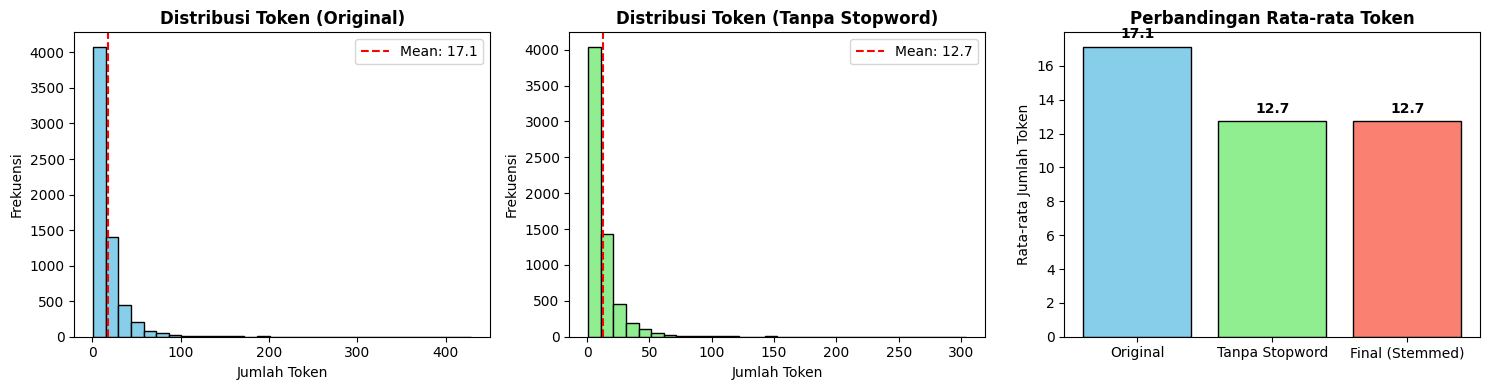


Word Cloud untuk setiap sentimen:


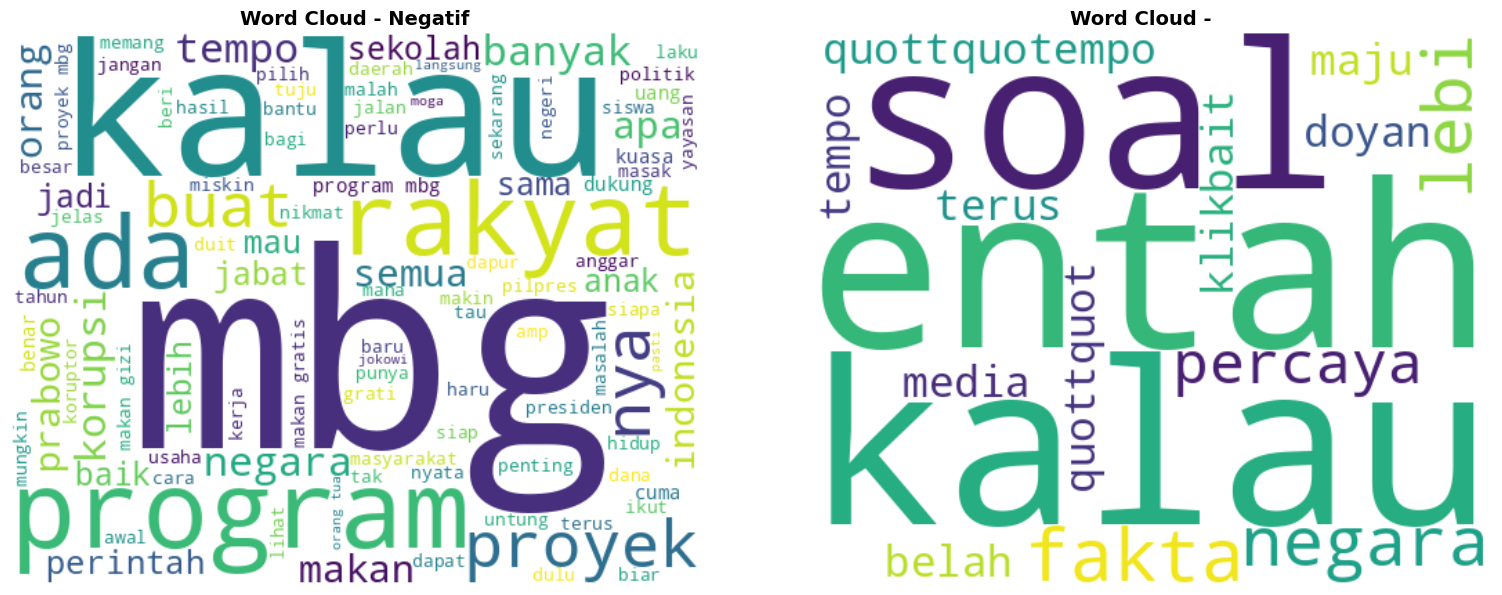


STATISTIK PER TAHAP:
No    Tahap                     Jumlah Unique        Contoh                        
--------------------------------------------------------------------------------
1     Text Cleaning             9                    penguasa dan pelaksana program
2     Normalization             9                    penguasa dan pelaksana program
3     Tokenization              5                    ['penguasa', 'dan', 'pelaksana
4     Stopword Removal          5                    ['penguasa', 'pelaksana', 'pro
5     Stemming                  5                    ['kuasa', 'laksana', 'program'

 PERBANDINGAN JUMLAH TOKEN:
  Rata-rata token awal         : 17.13
  Rata-rata token tanpa stopword: 12.73
  Rata-rata token final (stemmed): 12.73
  Reduksi token                 : 25.7%

 Dataset hasil preprocessing telah disimpan sebagai 'Data_Sentimen_MBG_Preprocessed.csv'


In [18]:
# VISUALISASI HASIL PREPROCESSINg

# Perbandingan jumlah token tiap tahap
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribusi token original
axes[0].hist(df_clean['jumlah_token'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Jumlah Token')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Token (Original)', fontweight='bold')
axes[0].axvline(df_clean['jumlah_token'].mean(), color='red', linestyle='--',
                label=f"Mean: {df_clean['jumlah_token'].mean():.1f}")
axes[0].legend()

# Distribusi token setelah stopword removal
axes[1].hist(df_clean['jumlah_token_tanpa_stopword'], bins=30, color='lightgreen', edgecolor='black')
axes[1].set_xlabel('Jumlah Token')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Token (Tanpa Stopword)', fontweight='bold')
axes[1].axvline(df_clean['jumlah_token_tanpa_stopword'].mean(), color='red', linestyle='--',
                label=f"Mean: {df_clean['jumlah_token_tanpa_stopword'].mean():.1f}")
axes[1].legend()

# Perbandingan rata-rata
labels = ['Original', 'Tanpa Stopword', 'Final (Stemmed)']
values = [
    df_clean['jumlah_token'].mean(),
    df_clean['jumlah_token_tanpa_stopword'].mean(),
    df_clean['tahap5_stemmed'].apply(len).mean()
]
axes[2].bar(labels, values, color=['skyblue', 'lightgreen', 'salmon'], edgecolor='black')
axes[2].set_ylabel('Rata-rata Jumlah Token')
axes[2].set_title('Perbandingan Rata-rata Token', fontweight='bold')
for i, v in enumerate(values):
    axes[2].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Word Cloud untuk setiap sentimen
print("\nWord Cloud untuk setiap sentimen:")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, sentimen in enumerate(df_clean['sentimen'].unique()):
    text = ' '.join(df_clean[df_clean['sentimen'] == sentimen]['teks_final'].tolist())
    wordcloud = WordCloud(width=500, height=400, background_color='white',
                         colormap='viridis', max_words=100).generate(text)

    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Word Cloud - {sentimen}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# RINGKASAN PREPROCESSING

print("\nSTATISTIK PER TAHAP:")
print(f"{'No':<5} {'Tahap':<25} {'Jumlah Unique':<20} {'Contoh':<30}")
print("-" * 80)

# Contoh data untuk ditampilkan
sample_text = df_clean['komentar'].iloc[0]
sample_cleaned = df_clean['tahap1_cleaned'].iloc[0]
sample_normalized = df_clean['tahap2_normalized'].iloc[0]
sample_tokens = df_clean['tahap3_tokens'].iloc[0][:5]
sample_no_stopword = df_clean['tahap4_no_stopwords'].iloc[0][:5]
sample_stemmed = df_clean['tahap5_stemmed'].iloc[0][:5]

print(f"{'1':<5} {'Text Cleaning':<25} {len(set(sample_cleaned.split())):<20} {str(sample_cleaned)[:30]:<30}")
print(f"{'2':<5} {'Normalization':<25} {len(set(sample_normalized.split())):<20} {str(sample_normalized)[:30]:<30}")
print(f"{'3':<5} {'Tokenization':<25} {len(sample_tokens):<20} {str(sample_tokens)[:30]:<30}")
print(f"{'4':<5} {'Stopword Removal':<25} {len(sample_no_stopword):<20} {str(sample_no_stopword)[:30]:<30}")
print(f"{'5':<5} {'Stemming':<25} {len(sample_stemmed):<20} {str(sample_stemmed)[:30]:<30}")

print("\n PERBANDINGAN JUMLAH TOKEN:")
print(f"  Rata-rata token awal         : {df_clean['jumlah_token'].mean():.2f}")
print(f"  Rata-rata token tanpa stopword: {df_clean['jumlah_token_tanpa_stopword'].mean():.2f}")
print(f"  Rata-rata token final (stemmed): {df_clean['tahap5_stemmed'].apply(len).mean():.2f}")
print(f"  Reduksi token                 : {(1 - df_clean['tahap5_stemmed'].apply(len).mean() / df_clean['jumlah_token'].mean()) * 100:.1f}%")

# Simpan hasil preprocessing
df_clean.to_csv('/content/Data_Sentimen_MBG_Preprocessed.csv', index=False)
print("\n Dataset hasil preprocessing telah disimpan sebagai 'Data_Sentimen_MBG_Preprocessed.csv'")


 Rentang waktu: 2025-04-18 s/d 2026-03-18
 Total hari: 175 hari
 Rata-rata komentar per hari: 36.37


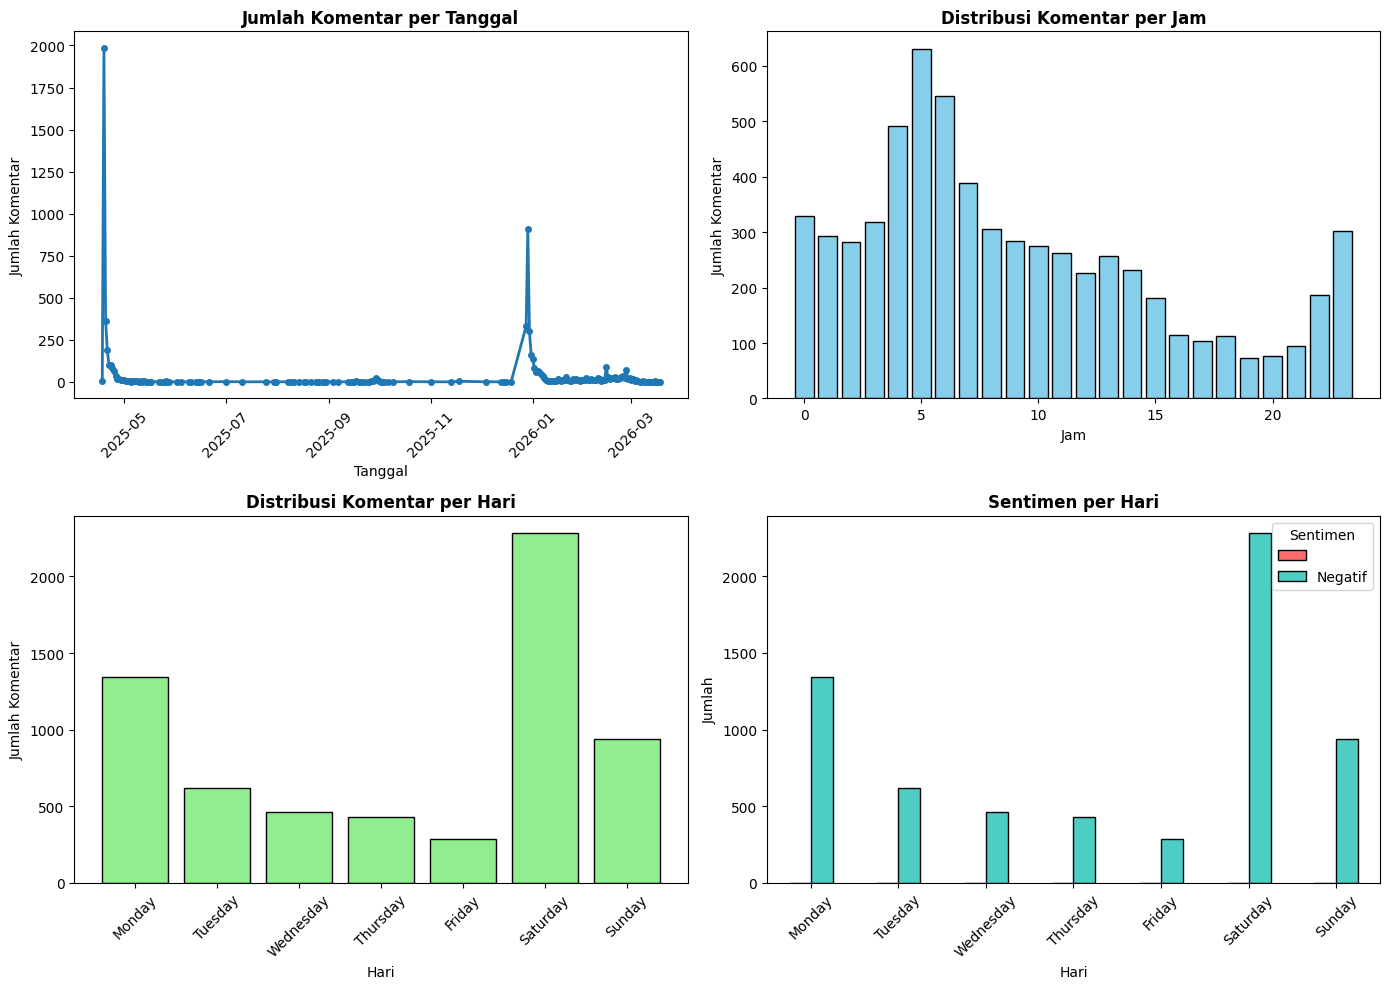


📊 Statistik Like Count:
   Total likes: 25118
   Rata-rata like: 3.95
   Median like: 0.0
   Max like: 2404
   Min like: 0
   Standar deviasi: 51.85

 Like Count per Sentimen:
               mean    sum  count
sentimen                         
          63.000000     63      1
Negatif    3.936989  25055   6364


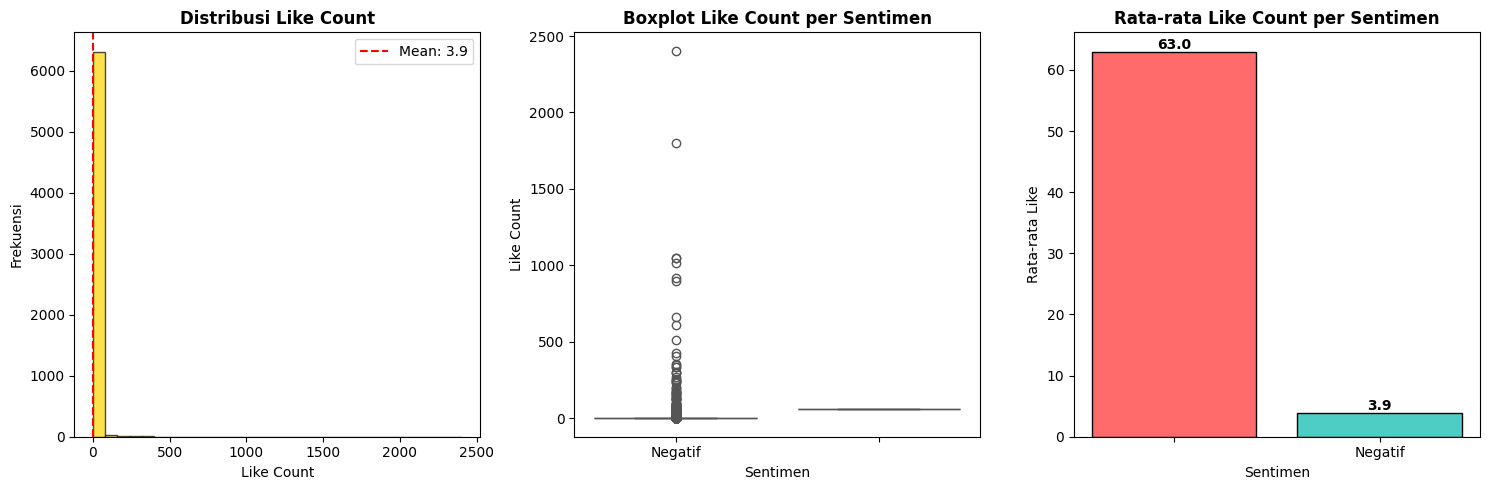


📊 Statistik Panjang Komentar (karakter):
   Rata-rata: 119.64 karakter
   Median: 78.00 karakter
   Terpendek: 1 karakter
   Terpanjang: 3350 karakter

📊 Statistik Jumlah Kata:
   Rata-rata: 17.63 kata
   Median: 12.00 kata
   Terpendek: 1 kata
   Terpanjang: 436 kata


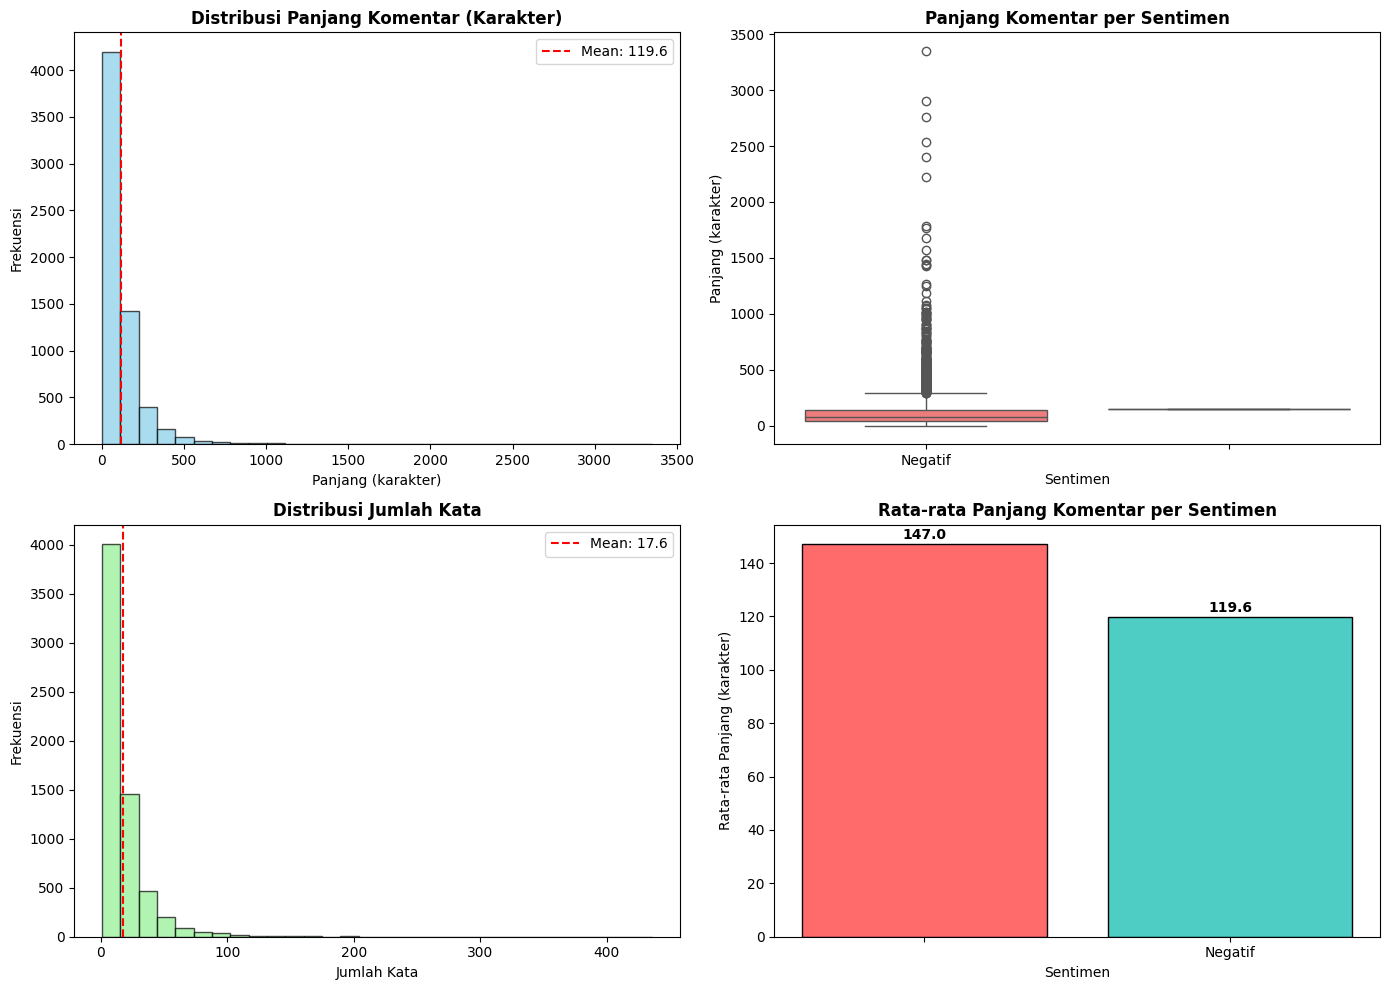


 Top 10 Author dengan Komentar Terbanyak:
   @fandiKeumala14-uk5qg: 15 komentar
   @JoharK-cg8zh: 12 komentar
   @GondoSierad: 9 komentar
   @masmunandar1662: 8 komentar
   @Siti-c8f: 7 komentar
   @pakkasturi7289: 6 komentar
   @ErnaIndrayanti-s9j: 6 komentar
   @AdeHamka-n6j: 6 komentar
   @RajaauliaKayobungsu-hl8ow: 5 komentar
   @sugandaba29: 5 komentar


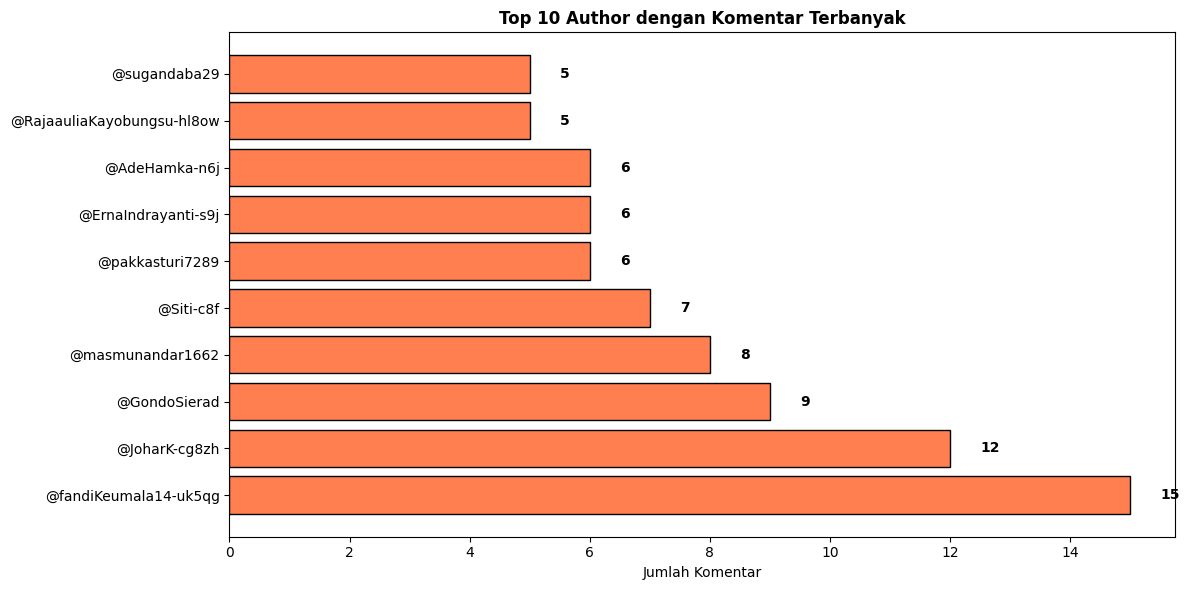


📌 Top 10 Kata untuk Sentimen 'Negatif':
   mbg: 2078x
   dan: 1775x
   ini: 1356x
   yang: 1254x
   ada: 1011x
   program: 970x
   itu: 826x
   rakyat: 744x
   untuk: 735x
   proyek: 715x

📌 Top 10 Kata untuk Sentimen ' ':
   entah: 1x
   mengapa: 1x
   kalo: 1x
   soal: 1x
   fakta: 1x
   negara: 1x
   lebi: 1x
   percaya: 1x
   quottquotempo: 1x
   daripada: 1x


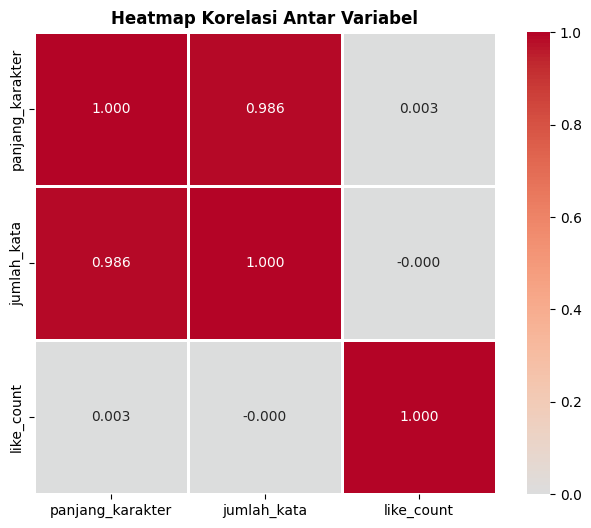


📊 Interpretasi Korelasi:
   - Panjang vs Jumlah Kata: 0.986 (sangat kuat)
   - Panjang vs Like: 0.003
   - Jumlah Kata vs Like: -0.000

10. RINGKASAN EDA

 RINGKASAN EKSPLORASI DATA:
--------------------------------------------------
1. Total Data: 6365 komentar
2. Jumlah Author Unik: 5813 author
3. Rentang Waktu: 2025-04-18 - 2026-03-18
4. Distribusi Sentimen:
   - Negatif: 6364 (100.0%)
   -  : 1 (0.0%)
5. Rata-rata Like: 3.95
6. Rata-rata Panjang Komentar: 119.64 karakter
7. Rata-rata Jumlah Kata: 17.63 kata

 Dataset dengan fitur EDA telah disimpan sebagai 'Data_Sentimen_MBG_EDA.csv'

✨ EDA Selesai! ✨


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')



# Konversi ke datetime
df_clean['published_at'] = pd.to_datetime(df_clean['published_at'], errors='coerce')
df_clean['tanggal'] = df_clean['published_at'].dt.date
df_clean['jam'] = df_clean['published_at'].dt.hour
df_clean['hari'] = df_clean['published_at'].dt.day_name()

# Komentar per tanggal
komentar_per_tanggal = df_clean.groupby('tanggal').size()
print(f"\n Rentang waktu: {df_clean['tanggal'].min()} s/d {df_clean['tanggal'].max()}")
print(f" Total hari: {len(komentar_per_tanggal)} hari")
print(f" Rata-rata komentar per hari: {komentar_per_tanggal.mean():.2f}")

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Komentar per tanggal
axes[0,0].plot(komentar_per_tanggal.index, komentar_per_tanggal.values, marker='o', linewidth=2, markersize=4)
axes[0,0].set_title('Jumlah Komentar per Tanggal', fontweight='bold')
axes[0,0].set_xlabel('Tanggal')
axes[0,0].set_ylabel('Jumlah Komentar')
axes[0,0].tick_params(axis='x', rotation=45)

# Komentar per jam
jam_counts = df_clean['jam'].value_counts().sort_index()
axes[0,1].bar(jam_counts.index, jam_counts.values, color='skyblue', edgecolor='black')
axes[0,1].set_title('Distribusi Komentar per Jam', fontweight='bold')
axes[0,1].set_xlabel('Jam')
axes[0,1].set_ylabel('Jumlah Komentar')

# Komentar per hari
hari_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hari_counts = df_clean['hari'].value_counts().reindex(hari_order)
axes[1,0].bar(hari_counts.index, hari_counts.values, color='lightgreen', edgecolor='black')
axes[1,0].set_title('Distribusi Komentar per Hari', fontweight='bold')
axes[1,0].set_xlabel('Hari')
axes[1,0].set_ylabel('Jumlah Komentar')
axes[1,0].tick_params(axis='x', rotation=45)

# Sentimen per hari
sentimen_per_hari = pd.crosstab(df_clean['hari'], df_clean['sentimen']).reindex(hari_order)
sentimen_per_hari.plot(kind='bar', ax=axes[1,1], color=['#ff6b6b', '#4ecdc4'], edgecolor='black')
axes[1,1].set_title('Sentimen per Hari', fontweight='bold')
axes[1,1].set_xlabel('Hari')
axes[1,1].set_ylabel('Jumlah')
axes[1,1].legend(title='Sentimen')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ANALISIS LIKE COUNT

print(f"\n📊 Statistik Like Count:")
print(f"   Total likes: {df_clean['like_count'].sum()}")
print(f"   Rata-rata like: {df_clean['like_count'].mean():.2f}")
print(f"   Median like: {df_clean['like_count'].median()}")
print(f"   Max like: {df_clean['like_count'].max()}")
print(f"   Min like: {df_clean['like_count'].min()}")
print(f"   Standar deviasi: {df_clean['like_count'].std():.2f}")

# Like per sentimen
like_per_sentimen = df_clean.groupby('sentimen')['like_count'].agg(['mean', 'sum', 'count'])
print(f"\n Like Count per Sentimen:")
print(like_per_sentimen)

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogram like count
axes[0].hist(df_clean['like_count'], bins=30, color='gold', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribusi Like Count', fontweight='bold')
axes[0].set_xlabel('Like Count')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df_clean['like_count'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['like_count'].mean():.1f}")
axes[0].legend()

# Boxplot like per sentimen
sns.boxplot(data=df_clean, x='sentimen', y='like_count', ax=axes[1], palette=['#ff6b6b', '#4ecdc4'])
axes[1].set_title('Boxplot Like Count per Sentimen', fontweight='bold')
axes[1].set_xlabel('Sentimen')
axes[1].set_ylabel('Like Count')

# Rata-rata like per sentimen
avg_likes = df_clean.groupby('sentimen')['like_count'].mean()
axes[2].bar(avg_likes.index, avg_likes.values, color=['#ff6b6b', '#4ecdc4'], edgecolor='black')
axes[2].set_title('Rata-rata Like Count per Sentimen', fontweight='bold')
axes[2].set_xlabel('Sentimen')
axes[2].set_ylabel('Rata-rata Like')
for i, v in enumerate(avg_likes.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 6. ANALISIS PANJANG KOMENTAR

# Hitung panjang komentar
df_clean['panjang_karakter'] = df_clean['komentar'].astype(str).apply(len)
df_clean['jumlah_kata'] = df_clean['komentar'].astype(str).apply(lambda x: len(str(x).split()))

print(f"\n📊 Statistik Panjang Komentar (karakter):")
print(f"   Rata-rata: {df_clean['panjang_karakter'].mean():.2f} karakter")
print(f"   Median: {df_clean['panjang_karakter'].median():.2f} karakter")
print(f"   Terpendek: {df_clean['panjang_karakter'].min()} karakter")
print(f"   Terpanjang: {df_clean['panjang_karakter'].max()} karakter")

print(f"\n📊 Statistik Jumlah Kata:")
print(f"   Rata-rata: {df_clean['jumlah_kata'].mean():.2f} kata")
print(f"   Median: {df_clean['jumlah_kata'].median():.2f} kata")
print(f"   Terpendek: {df_clean['jumlah_kata'].min()} kata")
print(f"   Terpanjang: {df_clean['jumlah_kata'].max()} kata")

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram panjang karakter
axes[0,0].hist(df_clean['panjang_karakter'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].set_title('Distribusi Panjang Komentar (Karakter)', fontweight='bold')
axes[0,0].set_xlabel('Panjang (karakter)')
axes[0,0].set_ylabel('Frekuensi')
axes[0,0].axvline(df_clean['panjang_karakter'].mean(), color='red', linestyle='--',
                  label=f"Mean: {df_clean['panjang_karakter'].mean():.1f}")
axes[0,0].legend()

# Boxplot panjang per sentimen
sns.boxplot(data=df_clean, x='sentimen', y='panjang_karakter', ax=axes[0,1], palette=['#ff6b6b', '#4ecdc4'])
axes[0,1].set_title('Panjang Komentar per Sentimen', fontweight='bold')
axes[0,1].set_xlabel('Sentimen')
axes[0,1].set_ylabel('Panjang (karakter)')

# Histogram jumlah kata
axes[1,0].hist(df_clean['jumlah_kata'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1,0].set_title('Distribusi Jumlah Kata', fontweight='bold')
axes[1,0].set_xlabel('Jumlah Kata')
axes[1,0].set_ylabel('Frekuensi')
axes[1,0].axvline(df_clean['jumlah_kata'].mean(), color='red', linestyle='--',
                  label=f"Mean: {df_clean['jumlah_kata'].mean():.1f}")
axes[1,0].legend()

# Rata-rata panjang per sentimen
avg_length = df_clean.groupby('sentimen')['panjang_karakter'].mean()
bars = axes[1,1].bar(avg_length.index, avg_length.values, color=['#ff6b6b', '#4ecdc4'], edgecolor='black')
axes[1,1].set_title('Rata-rata Panjang Komentar per Sentimen', fontweight='bold')
axes[1,1].set_xlabel('Sentimen')
axes[1,1].set_ylabel('Rata-rata Panjang (karakter)')
for bar, v in zip(bars, avg_length.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                   f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ANALISIS AUTHOR

# Top authors by comment count
top_authors = df_clean['author'].value_counts().head(10)
print(f"\n Top 10 Author dengan Komentar Terbanyak:")
for author, count in top_authors.items():
    print(f"   {author}: {count} komentar")

# Visualisasi top authors
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(top_authors)), top_authors.values, color='coral', edgecolor='black')
plt.yticks(range(len(top_authors)), top_authors.index)
plt.xlabel('Jumlah Komentar')
plt.title('Top 10 Author dengan Komentar Terbanyak', fontweight='bold')
for bar, count in zip(bars, top_authors.values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontweight='bold')
plt.tight_layout()
plt.show()



from collections import Counter

# Fungsi sederhana untuk ekstrak kata
def extract_words(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    # Hapus kata pendek (<3 karakter)
    words = [w for w in words if len(w) > 2]
    return words

# Ekstrak kata per sentimen
for sentiment in df_clean['sentimen'].unique():
    komentar_sentimen = df_clean[df_clean['sentimen'] == sentiment]['komentar'].tolist()
    all_words = []
    for komentar in komentar_sentimen:
        all_words.extend(extract_words(komentar))

    # Ambil top 10 kata
    word_counts = Counter(all_words)
    top_words = word_counts.most_common(10)

    print(f"\n📌 Top 10 Kata untuk Sentimen '{sentiment}':")
    for word, count in top_words:
        print(f"   {word}: {count}x")


# Korelasi antara panjang komentar, jumlah kata, dan like count
correlation_cols = ['panjang_karakter', 'jumlah_kata', 'like_count']
correlation_matrix = df_clean[correlation_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.3f')
plt.title('Heatmap Korelasi Antar Variabel', fontweight='bold')
plt.show()

print("\n📊 Interpretasi Korelasi:")
print(f"   - Panjang vs Jumlah Kata: {correlation_matrix.loc['panjang_karakter', 'jumlah_kata']:.3f} (sangat kuat)")
print(f"   - Panjang vs Like: {correlation_matrix.loc['panjang_karakter', 'like_count']:.3f}")
print(f"   - Jumlah Kata vs Like: {correlation_matrix.loc['jumlah_kata', 'like_count']:.3f}")

# ============================================
# 10. RINGKASAN EDA
# ============================================
print("\n" + "="*80)
print("10. RINGKASAN EDA")
print("="*80)

print("\n RINGKASAN EKSPLORASI DATA:")
print("-"*50)
print(f"1. Total Data: {len(df_clean)} komentar")
print(f"2. Jumlah Author Unik: {df_clean['author'].nunique()} author")
print(f"3. Rentang Waktu: {df_clean['tanggal'].min()} - {df_clean['tanggal'].max()}")
print(f"4. Distribusi Sentimen:")
sentiment_counts = df_clean['sentimen'].value_counts()
for sentimen, count in sentiment_counts.items():
    print(f"   - {sentimen}: {count} ({count/len(df_clean)*100:.1f}%)")
print(f"5. Rata-rata Like: {df_clean['like_count'].mean():.2f}")
print(f"6. Rata-rata Panjang Komentar: {df_clean['panjang_karakter'].mean():.2f} karakter")
print(f"7. Rata-rata Jumlah Kata: {df_clean['jumlah_kata'].mean():.2f} kata")

# Simpan hasil EDA
df_clean.to_csv('/content/Data_Sentimen_MBG_EDA.csv', index=False)
print(f"\n Dataset dengan fitur EDA telah disimpan sebagai 'Data_Sentimen_MBG_EDA.csv'")
print("\n✨ EDA Selesai! ✨")